# Short-Term Temperature Forecasting

## Business Context

The exploratory analysis provided a clear understanding of the dataset and the weather patterns observed across the selected cities.

The next step is to determine whether these historical observations can be used to forecast the maximum temperature for the following day.

This notebook develops and evaluates a simple forecasting approach designed to produce reliable next-day temperature predictions while maintaining an interpretable and reproducible machine learning pipeline.

In [22]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

## Loading the Prepared Dataset

The processed dataset produced during the exploratory analysis is loaded as the starting point for model development.

Using the prepared dataset ensures that the forecasting pipeline relies on validated observations and a consistent data structure throughout the modeling process.

In [23]:
weather_df = pd.read_csv("../data/processed/weather_2022_processed.csv")

weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.sort_values(["city", "time"])

weather_df.head().round(2)

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,city,month,rain_category,hot_category,cold_category,z_temp_max,z_temp_min,z_rain,temp_max_anomaly,temp_min_anomaly,rain_anomaly
5110,2022-01-01,12.9,8.9,0.0,Ajaccio,1,Dry (<1 mm),Normal day (<25°C),Normal night (0-20°C),-1.27,-0.55,-0.37,False,False,False
5111,2022-01-02,13.8,8.4,0.3,Ajaccio,1,Dry (<1 mm),Normal day (<25°C),Normal night (0-20°C),-1.15,-0.62,-0.32,False,False,False
5112,2022-01-03,15.1,8.3,0.1,Ajaccio,1,Dry (<1 mm),Normal day (<25°C),Normal night (0-20°C),-0.98,-0.64,-0.35,False,False,False
5113,2022-01-04,14.4,8.0,1.1,Ajaccio,1,Light rain (1-10 mm),Normal day (<25°C),Normal night (0-20°C),-1.07,-0.69,-0.20,False,False,False
5114,2022-01-05,13.7,8.7,8.9,Ajaccio,1,Light rain (1-10 mm),Normal day (<25°C),Normal night (0-20°C),-1.17,-0.58,0.95,False,False,False


## Feature Engineering

Machine learning models rely on informative input variables rather than raw observations alone.

Additional features are created to capture both seasonal patterns and short-term weather persistence, providing the model with information that may help improve next-day temperature forecasts.

These engineered variables will serve as the inputs used during model training.

In [24]:
weather_df["day_of_year"] = weather_df["time"].dt.dayofyear

weather_df["day_sin"] = np.sin(2 * np.pi * weather_df["day_of_year"] / 365)
weather_df["day_cos"] = np.cos(2 * np.pi * weather_df["day_of_year"] / 365)

## Feature Engineering – Lag Variables

Weather conditions often evolve progressively from one day to the next rather than changing abruptly.

To capture this short-term temporal continuity, the previous day's maximum and minimum temperatures are included as input features. These variables provide the forecasting model with recent observations that may help improve next-day temperature predictions.

In [25]:
weather_df["temp_max_lag1"] = weather_df.groupby("city")["temperature_2m_max"].shift(1)
weather_df["temp_min_lag1"] = weather_df.groupby("city")["temperature_2m_min"].shift(1)

## Defining the Prediction Target

Before training a forecasting model, the prediction objective must be clearly defined.

In this project, the target corresponds to the maximum temperature observed on the following day (J+1). This transforms the historical weather observations into a supervised learning problem, where past conditions are used to estimate the next day's temperature.

In [26]:
weather_df["target_temp_max_J1"] = weather_df.groupby("city")["temperature_2m_max"].shift(-1)

In [27]:
FEATURES = ["temp_max_lag1", "temp_min_lag1", "day_sin", "day_cos"]
TARGET = "target_temp_max_J1"

## Baseline Evaluation (Temporal Split)

Before evaluating machine learning models, it is important to establish a simple reference point.

Since this project deals with time-series data, the dataset is split chronologically rather than randomly. This ensures that predictions are always made using past observations to estimate future temperatures, reflecting how a forecasting model would be used in a real-world setting.

A baseline forecast assumes that tomorrow's maximum temperature will be similar to today's. Although intentionally simple, this approach provides a benchmark against which more advanced models can be objectively compared.

This reference helps determine whether machine learning delivers a meaningful improvement over a straightforward forecasting strategy.

In [28]:
SPLIT_DATE = pd.Timestamp("2022-10-01")

baseline_results = []

for city, city_df in weather_df.groupby("city"):

    city_df = city_df.sort_values("time")

    train = city_df[city_df["time"] < SPLIT_DATE]
    test  = city_df[city_df["time"] >= SPLIT_DATE]

    test = test.dropna(subset=FEATURES + [TARGET])

    y_test = test[TARGET]
    y_pred_naive = test["temp_max_lag1"]

    baseline_results.append({
        "city": city,
        "MAE_baseline": mean_absolute_error(y_test, y_pred_naive),
        "RMSE_baseline": np.sqrt(mean_squared_error(y_test, y_pred_naive))
    })

baseline_df = pd.DataFrame(baseline_results).round(2)
baseline_df



,city,MAE_baseline,RMSE_baseline
0,Ajaccio,1.67,2.24
1,Besançon,2.79,3.58
2,Bordeaux,2.92,3.66
3,Clermont-Ferrand,3.22,4.07
4,Dijon,2.31,2.97
5,Lille,2.05,2.69
6,Limoges,2.80,3.43
7,Lyon,2.64,3.52
8,Marseille,1.70,2.27
9,Metz,2.29,2.99


### Interpretation

The baseline model provides a reference level of forecasting performance for each city using a simple persistence assumption.

Prediction errors vary across locations, suggesting that next-day temperature is more predictable in some cities than in others.

These baseline results establish a consistent benchmark for assessing whether machine learning models provide additional predictive value.

## Comparing Candidate Models

Rather than selecting a forecasting model from the outset, several machine learning approaches are evaluated using the same training data and evaluation protocol.

Each model offers a different level of complexity, allowing us to assess whether increasing model sophistication leads to more accurate temperature forecasts.

The objective is not to identify the most complex model, but to select the one that provides the best balance between predictive performance and generalization.

In [29]:
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Polynomial_2": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("reg", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("reg", Ridge(alpha=1.0))
    ])
}


## Time-Series Cross-Validation

To compare candidate models fairly, each one is evaluated using time-series cross-validation.

Unlike a single train-test split, this approach repeats the evaluation across multiple chronological splits while always preserving the temporal order of the observations. This provides a more reliable assessment of how each model performs under different forecasting conditions.

The resulting evaluation metrics will be used to identify the model that delivers the most consistent predictive performance.

In [30]:
cv_results = []

for city, city_df in weather_df.groupby("city"):

    city_df = city_df.sort_values("time")
    city_df = city_df.dropna(subset=FEATURES + [TARGET])

    X = city_df[FEATURES]
    y = city_df[TARGET]

    tscv = TimeSeriesSplit(n_splits=5)

    for model_name, model in models.items():

        maes = []

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            maes.append(mean_absolute_error(y_test, y_pred))

        cv_results.append({
            "city": city,
            "model": model_name,
            "MAE_mean": np.mean(maes),
            "MAE_std": np.std(maes)
        })

cv_results_df = pd.DataFrame(cv_results).round(2)
cv_results_df


,city,model,MAE_mean,MAE_std
0,Ajaccio,Linear,3.60,2.24
1,Ajaccio,Polynomial_2,19.55,23.69
2,Ajaccio,Ridge,13.90,14.13
3,Besançon,Linear,4.00,1.20
4,Besançon,Polynomial_2,21.89,30.45
5,Besançon,Ridge,16.17,22.17
6,Bordeaux,Linear,3.32,0.67
7,Bordeaux,Polynomial_2,19.89,27.20
8,Bordeaux,Ridge,15.25,19.43
9,Clermont-Ferrand,Linear,3.59,0.88


## Model Selection

After evaluating each candidate model under the same validation strategy, their overall performance can be compared.

The average prediction error across all cities is used as the selection criterion, ensuring that the chosen model performs consistently rather than excelling only in specific cases.

The selected model will then be trained and evaluated individually for each city.

In [31]:
model_performance = (
    cv_results_df
    .groupby("model")["MAE_mean"]
    .mean()
    .sort_values()
)

model_performance.round(2)


model
Linear           3.31
Ridge           12.80
Polynomial_2    19.48
Name: MAE_mean, dtype: float64

In [32]:
FINAL_MODEL_NAME = model_performance.index[0]
FINAL_MODEL_NAME

'Linear'

### Interpretation

Among the evaluated approaches, the **Linear Regression** model achieves the lowest average MAE across the selected cities.

Despite its simplicity, it outperforms the more complex polynomial-based models on this dataset, suggesting that increasing model complexity does not necessarily improve forecasting performance.

Based on these results, the linear model is selected for the remainder of the project.

## Final model training and evaluation

Following the model comparison, the best-performing algorithm is trained independently for each city using the historical training period.

The resulting models are then evaluated on unseen observations from the test period to estimate how well they generalize to future weather conditions.

Performance is assessed using complementary regression metrics, providing a balanced view of prediction accuracy across all selected cities.

In [33]:
final_results = []
predictions_all = []

for city, city_df in weather_df.groupby("city"):

    city_df = city_df.sort_values("time")

    train = city_df[city_df["time"] < SPLIT_DATE]
    test  = city_df[city_df["time"] >= SPLIT_DATE]

    train = train.dropna(subset=FEATURES + [TARGET])
    test  = test.dropna(subset=FEATURES + [TARGET])

    X_train, y_train = train[FEATURES], train[TARGET]
    X_test,  y_test  = test[FEATURES],  test[TARGET]

    model = clone(models[FINAL_MODEL_NAME])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    final_results.append({
        "city": city,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })

    tmp = test[["time", "city", TARGET]].copy()
    tmp["prediction"] = y_pred
    predictions_all.append(tmp)

final_results_df = pd.DataFrame(final_results).round(2)
final_results_df

,city,MAE,RMSE,R2
0,Ajaccio,1.60,2.06,0.75
1,Besançon,3.04,3.88,0.63
2,Bordeaux,2.77,3.35,0.70
3,Clermont-Ferrand,3.58,4.27,0.63
4,Dijon,2.52,3.15,0.75
5,Lille,2.70,3.39,0.67
6,Limoges,2.65,3.31,0.71
7,Lyon,2.91,3.56,0.72
8,Marseille,1.63,2.05,0.78
9,Metz,2.66,3.24,0.74


### Interpretation

The selected model achieves consistent performance across the twenty cities included in the study.

Mean Absolute Error (MAE) values generally range between **1.6°C and 3.6°C**, while the coefficient of determination (R²) remains between **0.63 and 0.78**, indicating that the model captures a substantial part of the day-to-day temperature variability.

Performance differences between cities are expected, as local weather conditions and climatic variability influence forecasting difficulty. Overall, the results suggest that the selected model provides stable and reliable short-term temperature predictions across diverse locations.

## Model persistence

Once the evaluation is complete, the selected model is retrained using all available observations for each city.

The trained models are then saved to disk, making them available for reuse without repeating the training process.

This persistence step prepares the models for integration into the decision-support application developed in the final stage of the project.

In [34]:
# Save trained models (one model per city)

os.makedirs("../models", exist_ok=True)

for city, city_df in weather_df.groupby("city"):

    city_df = city_df.sort_values("time")
    city_df = city_df.dropna(subset=FEATURES + [TARGET])

    X = city_df[FEATURES]
    y = city_df[TARGET]

    model = clone(models[FINAL_MODEL_NAME])
    model.fit(X, y)

    joblib.dump(model, f"../models/{city}_model.pkl")

print("Models saved in /models")

Models saved in /models


## Prediction examples

To better understand the model behavior, predictions are visualized for three representative cities:

- the city with the lowest prediction error (best case),
- a city with median performance,
- the city with the highest prediction error (worst case).

Comparing predicted and observed temperatures provides a qualitative assessment of how well the model captures daily temperature dynamics across different climatic conditions.

The following section summarizes these observations and compares the final model with the baseline approach.

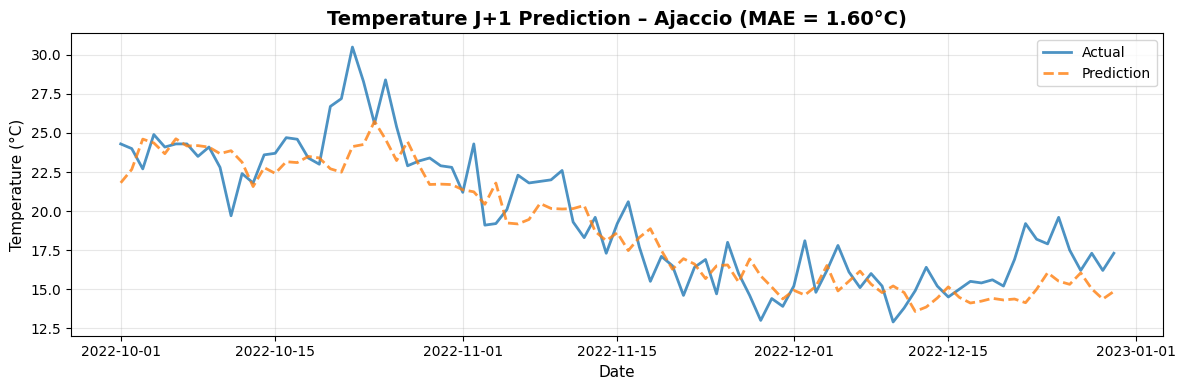

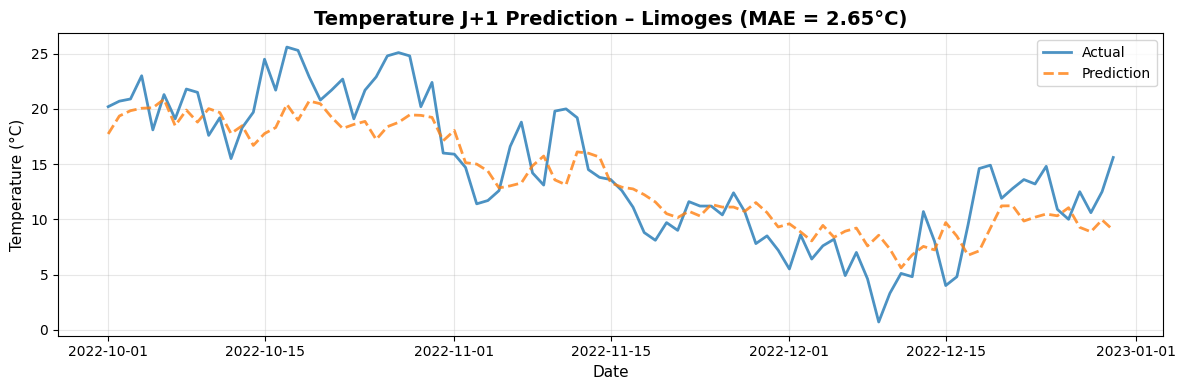

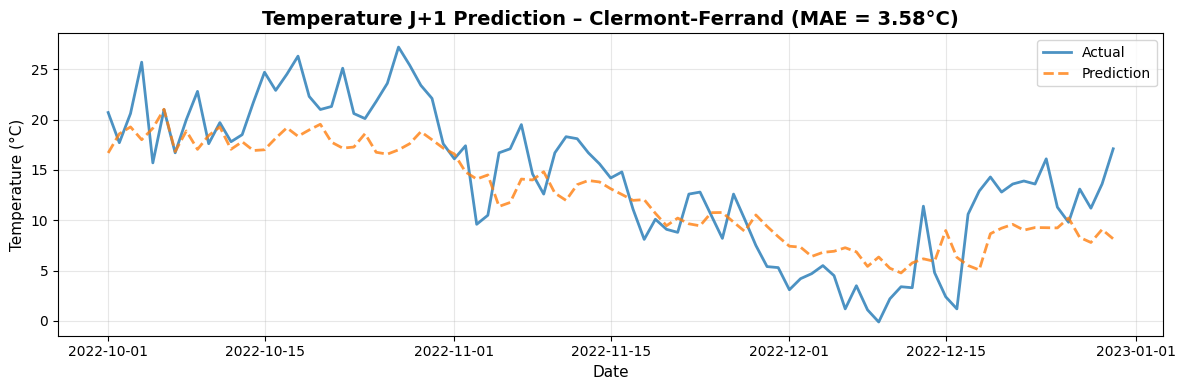

In [35]:
# Concat predictions first
pred_df = pd.concat(predictions_all, ignore_index=True)

# Select representative cities
city_perf = final_results_df.sort_values("MAE")
selected_cities = [
    city_perf.iloc[0]["city"],                    # best
    city_perf.iloc[len(city_perf)//2]["city"],    # median
    city_perf.iloc[-1]["city"]                    # worst
]

# Plot for each selected city
for city in selected_cities:
    city_data = pred_df[pred_df["city"] == city]
    mae_value = final_results_df[final_results_df["city"] == city]["MAE"].values[0]
    
    plt.figure(figsize=(12, 4))
    plt.plot(city_data["time"], city_data[TARGET], label="Actual", alpha=0.8, linewidth=2)
    plt.plot(city_data["time"], city_data["prediction"], label="Prediction", alpha=0.8, linewidth=2, linestyle='--')
    
    plt.title(f"Temperature J+1 Prediction – {city} (MAE = {mae_value:.2f}°C)", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=11)
    plt.ylabel("Temperature (°C)", fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


### Interpretation

Across the three representative cities, the model successfully follows the overall seasonal evolution of daily maximum temperature.

In the best-performing city (Ajaccio), predicted temperatures remain close to the observed values throughout the evaluation period, with only small deviations during rapid temperature changes.

For the median-performing city (Limoges), the model captures the general trend but tends to smooth short-term fluctuations, resulting in larger prediction errors.

The worst-performing city (Clermont-Ferrand) exhibits greater day-to-day variability, making sudden temperature changes more difficult to predict. Although the model still reproduces the overall seasonal pattern, it underestimates several sharp peaks and drops.

Overall, the model appears effective at learning long-term temperature dynamics, while remaining less accurate during abrupt local weather variations.

## Comparison with the baseline

The final step compares the selected model with the naïve baseline for each city.

This comparison quantifies whether the machine learning model provides a measurable improvement over simply using the previous day's temperature as the prediction.

In [36]:
summary_df = baseline_df.merge(final_results_df, on="city", how="inner")

summary_df["MAE_gain_vs_baseline"] = (
    (summary_df["MAE_baseline"] - summary_df["MAE"]) / summary_df["MAE_baseline"]
)

summary_df.round(2)

,city,MAE_baseline,RMSE_baseline,MAE,RMSE,R2,MAE_gain_vs_baseline
0,Ajaccio,1.67,2.24,1.60,2.06,0.75,0.04
1,Besançon,2.79,3.58,3.04,3.88,0.63,-0.09
2,Bordeaux,2.92,3.66,2.77,3.35,0.70,0.05
3,Clermont-Ferrand,3.22,4.07,3.58,4.27,0.63,-0.11
4,Dijon,2.31,2.97,2.52,3.15,0.75,-0.09
5,Lille,2.05,2.69,2.70,3.39,0.67,-0.32
6,Limoges,2.80,3.43,2.65,3.31,0.71,0.05
7,Lyon,2.64,3.52,2.91,3.56,0.72,-0.10
8,Marseille,1.70,2.27,1.63,2.05,0.78,0.04
9,Metz,2.29,2.99,2.66,3.24,0.74,-0.16


### Interpretation

The comparison with the naïve baseline shows mixed results across cities.

For a few cities, including Ajaccio, Bordeaux, Limoges, Marseille, and Montpellier, the machine learning model slightly improves prediction accuracy compared with simply using the previous day's temperature.

However, for most cities, the improvement is limited or even negative, indicating that the baseline remains a strong competitor for short-term temperature forecasting.

This behavior is expected given the characteristics of the project. The model is trained on a single year of observations and relies on a limited set of predictors, mainly the previous day's temperatures and seasonal information. Under these conditions, a simple persistence-based forecast already provides a strong reference, making substantial improvements difficult to achieve.

Despite these limitations, the selected model captures the overall temporal dynamics and produces consistent predictions across all cities, providing a solid baseline that could be further improved by incorporating additional historical data and meteorological variables.

## Prediction vs actual temperature

After evaluating the model at the city level, we now assess its overall behaviour by comparing every predicted temperature with its corresponding observed value.

Each point represents one prediction, while the red diagonal corresponds to a perfect prediction where the predicted and observed temperatures are identical.

Aggregate metrics such as MAE or RMSE provide a numerical summary of the model's performance, but they do not reveal systematic prediction patterns.

This visualization helps identify whether the model tends to systematically overestimate or underestimate temperatures and whether prediction errors increase for certain temperature ranges.

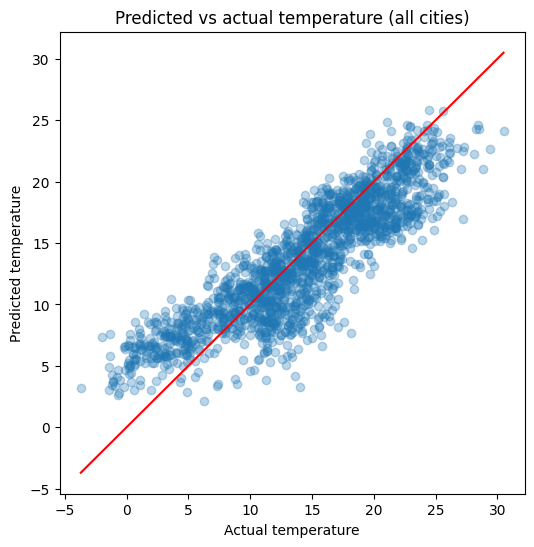

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df[TARGET], pred_df["prediction"], alpha=0.3)

min_val = min(pred_df[TARGET].min(), pred_df["prediction"].min())
max_val = max(pred_df[TARGET].max(), pred_df["prediction"].max())

plt.plot([min_val, max_val], [min_val, max_val], color="red")
plt.xlabel("Actual temperature")
plt.ylabel("Predicted temperature")
plt.title("Predicted vs actual temperature (all cities)")
plt.show()
plt.close()


### Interpretation

The predictions follow the general trend of the observed temperatures, as most points are concentrated around the diagonal reference line.

However, the dispersion around this line indicates that prediction errors remain, particularly for more extreme temperatures. The model tends to smooth sudden variations, producing estimates that stay closer to the average than the actual observations.

Overall, the scatter plot confirms that the selected model captures the global relationship between consecutive daily temperatures while remaining limited in reproducing abrupt weather changes, which is consistent with the evaluation metrics obtained previously.

## Save predictions for application

The final predictions generated by the selected model are exported to a dedicated directory.

Saving the predictions allows them to be reused independently of the training process. This avoids recomputing forecasts every time they are needed and makes them readily available for downstream applications or analyses.

With both the trained models and their predictions now stored, the complete forecasting pipeline is ready to be integrated into a practical workflow.

In [38]:
os.makedirs("../data/predictions", exist_ok=True)

pred_df.to_csv("../data/predictions/weather_predictions_2022_J1.csv", index=False)

print("Predictions saved to data/predictions/weather_predictions_2022_J1.csv")

Predictions saved to data/predictions/weather_predictions_2022_J1.csv


## Conclusion

This notebook completed the machine learning stage of the project by building, validating and evaluating a short-term temperature forecasting model.

Starting from the processed dataset, temporal features were engineered to capture both seasonal patterns and the influence of previous-day temperatures. Several regression approaches were compared using a time-aware validation strategy before selecting the model that provided the most reliable and consistent performance across the twenty French cities.

The trained models and their associated predictions were then exported as reusable artefacts. Rather than remaining limited to experimentation, these outputs are now available to generate daily forecasts efficiently without repeating the entire training process.

With data preparation, model development and prediction generation completed, the project now reaches the point where these artefacts can support a complete forecasting workflow and deliver temperature predictions in a practical, user-oriented environment.